# Early Warning for Student Attrition
## An Explainable and Fair Machine Learning Approach

### 02 — Exploratory Analysis

This notebook explores patterns in the student dataset before feature engineering or model development.

Main questions:
1. Which enrollment-stage characteristics are associated with dropout?
2. How much stronger do the relationships become after Semester 1 information is available?
3. Are there unusual distributions or extreme values that need special treatment?
4. How do dropout rates vary across demographic and socioeconomic groups?
5. Which findings should guide feature engineering and model development?

This notebook is exploratory and does not make causal claims.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)


## Colab Setup

Clone the project repository when running this notebook in Google Colab.

In [4]:
from pathlib import Path

repo_dir = Path("/content/student-dropout-capstone")

if not repo_dir.exists():
    !git clone https://github.com/rayvaril/student-dropout-capstone.git

%cd /content/student-dropout-capstone/notebooks

Cloning into 'student-dropout-capstone'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 62 (delta 21), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 197.46 KiB | 3.87 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/student-dropout-capstone/notebooks


## 2. Load the Dataset

The raw file remains unchanged. A working copy is created for analysis.


In [5]:
candidate_paths = [
    Path("../data/data.csv"),
    Path("data/data.csv"),
    Path("/content/data.csv")
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "data.csv was not found. Place the UCI dataset in the repository's data folder "
        "or upload it to the current Colab session."
    )

df_raw = pd.read_csv(data_path, sep=None, engine="python")

def clean_feature_name(name):
    return (
        str(name)
        .replace("\ufeff", "")
        .replace("\t", " ")
        .strip()
    )

df = df_raw.copy()
df.columns = [clean_feature_name(col) for col in df.columns]

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Shape: 4,424 rows × 37 columns


## 3. Create the Binary Dropout Target

The original UCI target has three outcomes: `Dropout`, `Enrolled`, and `Graduate`.

For the main capstone question:
- `1` = Dropout
- `0` = Non-Dropout (`Enrolled` or `Graduate`)

The original `Target` column is preserved.


In [7]:
df["Dropout_binary"] = (df["Target"] == "Dropout").astype(int)

binary_target_summary = (
    df["Dropout_binary"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Non-Dropout", 1: "Dropout"})
    .to_frame("count")
)

binary_target_summary["percentage"] = (
    binary_target_summary["count"] / len(df) * 100
).round(2)

binary_target_summary


,count,percentage
Dropout_binary,,
Non-Dropout,3003,67.88
Dropout,1421,32.12


In [ ]:
ax = binary_target_summary["count"].plot(kind="bar")
ax.set_title("Binary Target Distribution")
ax.set_xlabel("Outcome")
ax.set_ylabel("Number of Students")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Define Feature Groups


In [8]:
semester1_features = [col for col in df.columns if "1st sem" in col.lower()]
semester2_features = [col for col in df.columns if "2nd sem" in col.lower()]
external_context_features = ["Unemployment rate", "Inflation rate", "GDP"]

excluded_columns = set(
    semester1_features
    + semester2_features
    + external_context_features
    + ["Target", "Dropout_binary"]
)

enrollment_features = [col for col in df.columns if col not in excluded_columns]

print(f"Enrollment-stage features: {len(enrollment_features)}")
print(f"Semester 1 features: {len(semester1_features)}")
print(f"Semester 2 features: {len(semester2_features)}")
print(f"External-context features: {len(external_context_features)}")


Enrollment-stage features: 21
Semester 1 features: 6
Semester 2 features: 6
External-context features: 3


## 5. Enrollment-Stage Numerical Distributions


In [9]:
enrollment_numeric = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment"
]

df[enrollment_numeric].describe().T


,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),4424.0,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Admission grade,4424.0,126.978119,14.482001,95.0,117.9,126.1,134.8,190.0
Age at enrollment,4424.0,23.265145,7.587816,17.0,19.0,20.0,25.0,70.0


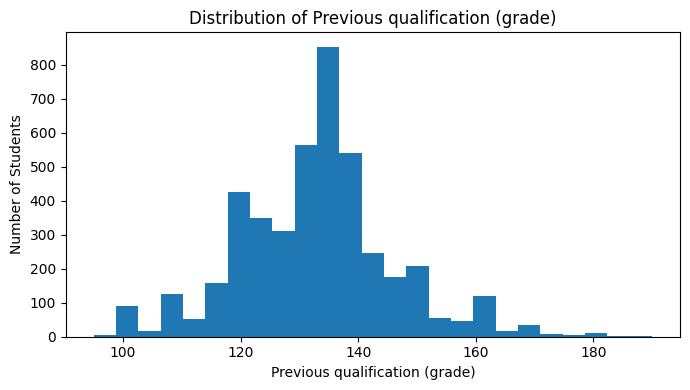

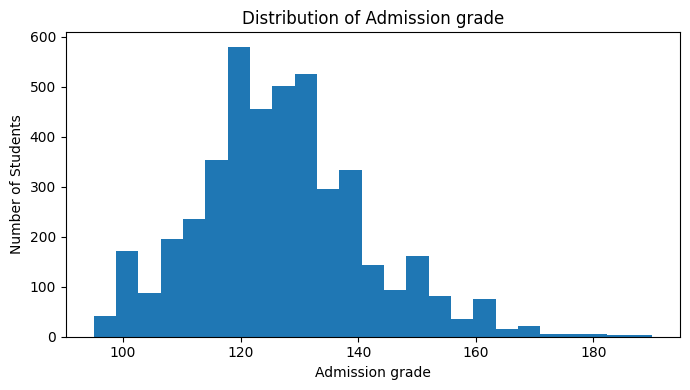

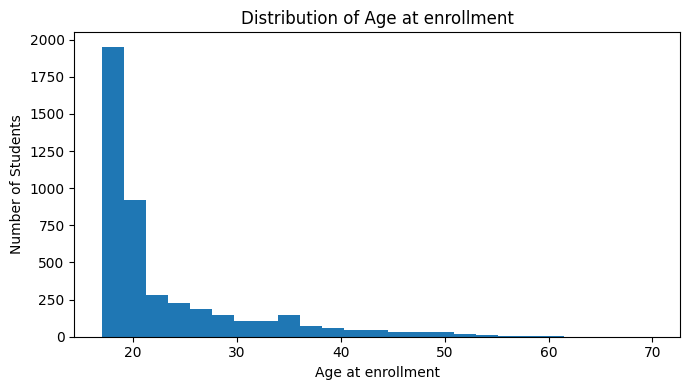

In [10]:
for col in enrollment_numeric:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=25)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Students")
    plt.tight_layout()
    plt.show()


**Assessment**

The enrollment-stage numerical variables do not show obvious data-quality issues.

`Previous qualification (grade)` and `Admission grade` are concentrated around the middle of their respective ranges, with relatively fewer observations at the extremes. No transformation or removal is justified at this stage.

`Age at enrollment` is strongly right-skewed. Most students entered higher education in their late teens or early twenties, while a smaller group enrolled at older ages. These older observations appear plausible and will be retained rather than treated automatically as outliers.

Age will remain continuous for predictive modeling. Age groups may later be created separately for subgroup and fairness analysis.

Any scaling or transformation decisions will be made during feature engineering and will depend on the model being used.

## 6. Enrollment-Stage Numerical Features vs. Dropout


In [11]:
enrollment_numeric_by_target = (
    df.groupby("Dropout_binary")[enrollment_numeric]
      .agg(["mean", "median", "std"])
)

enrollment_numeric_by_target


Previous qualification (grade)                    \
                                         mean median        std   
Dropout_binary                                                    
0                                  133.322744  133.1  13.278010   
1                                  131.114075  133.1  12.873354   

               Admission grade                   Age at enrollment         \
                          mean median        std              mean median   
Dropout_binary                                                              
0                   127.932434  126.7  14.069637         21.938395   19.0   
1                   124.961365  123.6  15.125159         26.068966   23.0   

                          
                     std  
Dropout_binary            
0               6.596226  
1               8.704024

### Assessment

Dropout students show slightly lower previous-qualification and admission grades on average than non-dropout students.

The clearest difference at this stage is age at enrollment: students who dropped out were older on average than students who did not.

These are descriptive differences only. The amount of overlap between the groups still needs to be checked before deciding how useful these variables may be for prediction.

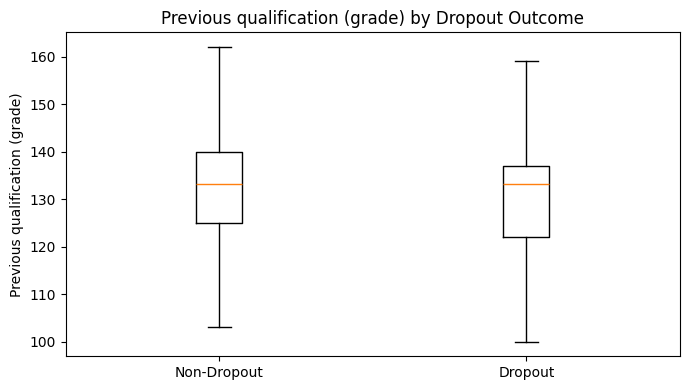

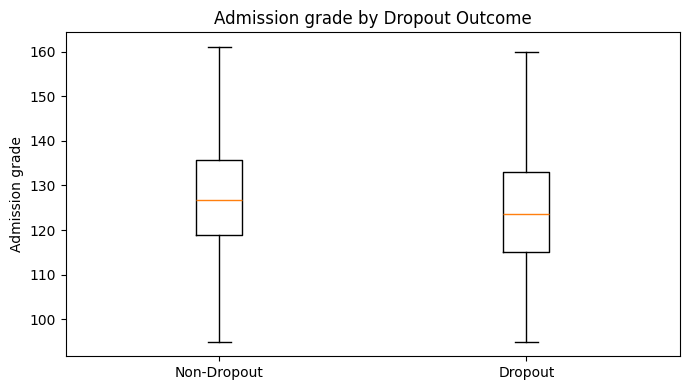

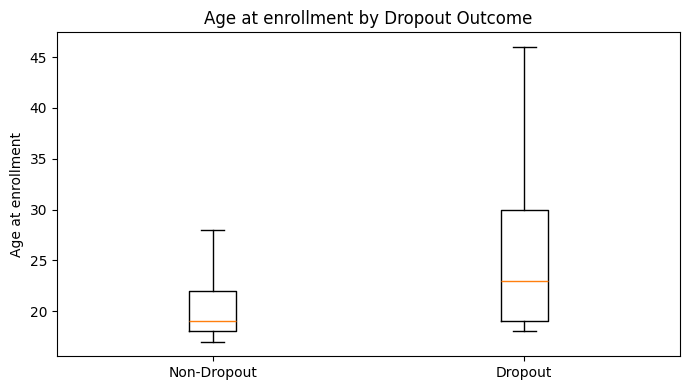

In [15]:
for col in enrollment_numeric:
    non_dropout_vals = df.loc[df["Dropout_binary"] == 0, col]
    dropout_vals = df.loc[df["Dropout_binary"] == 1, col]

    plt.figure(figsize=(7, 4))
    plt.boxplot(
        [non_dropout_vals, dropout_vals],
        tick_labels=["Non-Dropout", "Dropout"],
        showfliers=False
    )
    plt.title(f"{col} by Dropout Outcome")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### **Boxplot Assessment**

The boxplots show substantial overlap between dropout and non-dropout students for both previous-qualification grade and admission grade.

Previous-qualification grade shows only limited visual separation between the two groups. Admission grade shows a somewhat clearer difference, with dropout students tending to have lower values, although the distributions still overlap considerably.

Age at enrollment shows the clearest difference among the three variables. Dropout students have a higher median age and a wider age distribution than non-dropout students.

These patterns suggest that age and admission grade may provide useful enrollment-stage information, but none of these variables should be interpreted as sufficient predictors on their own.

## 7. Dropout Rates Across Key Enrollment Categories

These are associations only. A higher dropout rate in a group does not imply causation.


In [16]:
key_categorical_features = [
    "Gender",
    "Scholarship holder",
    "Debtor",
    "Tuition fees up to date",
    "Displaced",
    "Daytime/evening attendance",
    "Educational special needs",
    "International"
]

def dropout_rate_table(feature):
    summary = (
        df.groupby(feature)["Dropout_binary"]
          .agg(["count", "mean"])
          .rename(columns={"mean": "dropout_rate"})
          .reset_index()
    )
    summary["dropout_rate"] = (summary["dropout_rate"] * 100).round(2)
    return summary.sort_values("dropout_rate", ascending=False)

for feature in key_categorical_features:
    print(f"\n--- {feature} ---")
    display(dropout_rate_table(feature))



--- Gender ---


,Gender,count,dropout_rate
1,1,1556,45.05
0,0,2868,25.10



--- Scholarship holder ---


,Scholarship holder,count,dropout_rate
0,0,3325,38.71
1,1,1099,12.19



--- Debtor ---


...

,Daytime/evening attendance,count,dropout_rate
0,0,483,42.86
1,1,3941,30.80



--- Educational special needs ---


,Educational special needs,count,dropout_rate
1,1,51,33.33
0,0,4373,32.11



--- International ---


,International,count,dropout_rate
0,0,4314,32.20
1,1,110,29.09


### **Assessment**

Several enrollment-stage categorical variables show substantial differences in dropout rates.

The largest gaps appear in financial and administrative variables. Students whose tuition fees were not up to date had a much higher dropout rate than students whose tuition was current. Debtor status also showed a large difference, while scholarship holders had a considerably lower dropout rate than non-scholarship holders.

Differences were also observed across gender, attendance schedule, and displaced status.

These results are descriptive associations and do not imply causation. In particular, demographic differences such as gender will require careful interpretation and later fairness analysis.

`Educational special needs` and `International` have relatively small minority-group counts, so differences in their dropout rates should not be over-interpreted.

The strong differences associated with `Debtor` and `Tuition fees up to date` make it especially important to verify that these variables are available at the intended enrollment-stage prediction point before using them in the early-warning model.

## 8. Visualize Selected Enrollment-Stage Dropout Rates


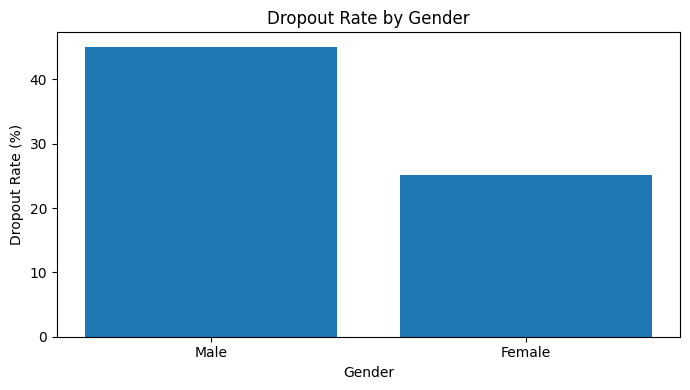

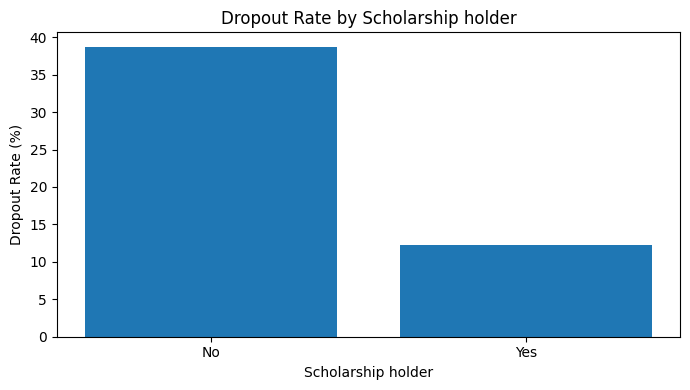

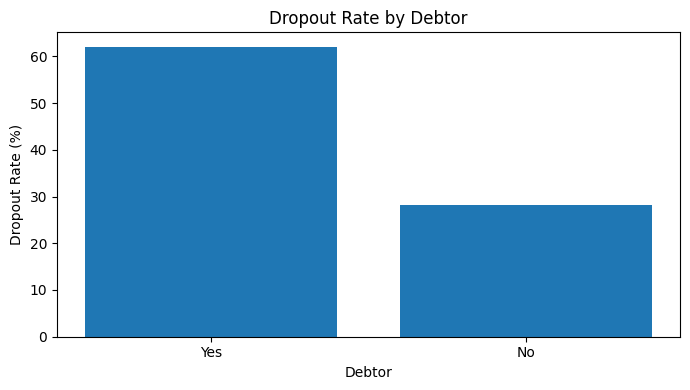

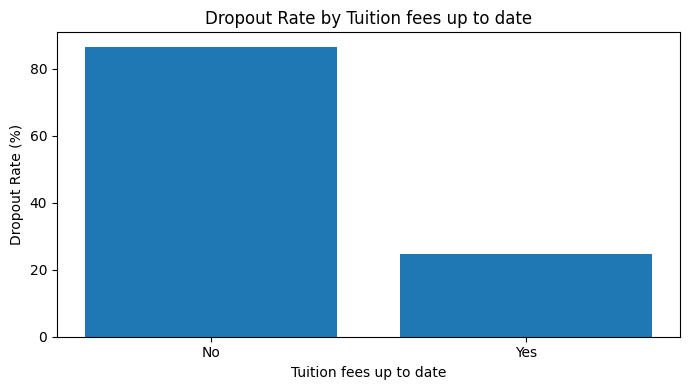

In [18]:
label_maps = {
    "Gender": {1: "Male", 0: "Female"},
    "Scholarship holder": {1: "Yes", 0: "No"},
    "Debtor": {1: "Yes", 0: "No"},
    "Tuition fees up to date": {1: "Yes", 0: "No"}
}

selected_rate_features = [
    "Gender",
    "Scholarship holder",
    "Debtor",
    "Tuition fees up to date"
]

for feature in selected_rate_features:
    rate_df = dropout_rate_table(feature).copy()
    rate_df["label"] = rate_df[feature].map(label_maps[feature])

    plt.figure(figsize=(7, 4))
    plt.bar(
        rate_df["label"],
        rate_df["dropout_rate"]
    )
    plt.title(f"Dropout Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Dropout Rate (%)")
    plt.tight_layout()
    plt.show()


### **Assessment**

The visual comparison reinforces the differences observed in the categorical summaries.

The largest dropout-rate gap appears for tuition-payment status, followed by debtor status and scholarship status. Gender also shows a noticeable difference between groups.

These results suggest that financial and administrative variables may provide useful early-warning information. However, these are univariate associations only and should not be interpreted as causal relationships or as final measures of predictive importance.

Gender will be treated separately in later fairness analysis rather than interpreted only as a predictive feature.

## 9. Course and Application Patterns

Group size and dropout rate are shown together so that small categories are not over-interpreted.


In [19]:
for feature in ["Course", "Application mode"]:
    summary = dropout_rate_table(feature)
    summary = summary.sort_values(["count", "dropout_rate"], ascending=[False, False])

    print(f"\n--- {feature} ---")
    display(summary)



--- Course ---


,Course,count,dropout_rate
11,9500,766,15.40
8,9147,380,35.26
9,9238,355,18.31
5,9085,337,26.71
14,9773,331,30.51
16,9991,268,50.75
13,9670,268,35.45
10,9254,252,38.10
4,9070,226,22.57
1,171,215,38.14



--- Application mode ---


,Application mode,count,dropout_rate
0,1,1708,20.20
7,17,872,29.36
11,39,785,55.41
13,43,312,36.86
14,44,213,29.58
3,7,139,61.15
8,18,124,36.29
12,42,77,44.16
15,51,59,33.90
6,16,38,13.16


### **Assessment**

Both `Course` and `Application mode` show meaningful differences in dropout rates across categories.

For `Course`, several groups with substantial sample sizes show noticeably different dropout rates. For example, some courses have dropout rates above 50%, while others are below 20%.

`Application mode` also shows clear differences among the larger categories. However, several application-mode categories contain very few students, making their dropout rates unstable and unsuitable for interpretation on their own.

The same issue appears in some course categories with small sample sizes.

Both variables will be retained for now. During feature engineering, rare categories may be grouped to reduce sparsity and improve model stability. Official UCI category labels will also be used where possible to make interpretation easier.

## 10. Semester 1 Academic Profile


In [20]:
df[semester1_features].describe().T


,count,mean,std,min,25%,50%,75%,max
Curricular units 1st sem (credited),4424.0,0.709991,2.360507,0.0,0.0,0.000000,0.0,20.000
Curricular units 1st sem (enrolled),4424.0,6.270570,2.480178,0.0,5.0,6.000000,7.0,26.000
Curricular units 1st sem (evaluations),4424.0,8.299051,4.179106,0.0,6.0,8.000000,10.0,45.000
Curricular units 1st sem (approved),4424.0,4.706600,3.094238,0.0,3.0,5.000000,6.0,26.000
Curricular units 1st sem (grade),4424.0,10.640822,4.843663,0.0,11.0,12.285714,13.4,18.875
Curricular units 1st sem (without evaluations),4424.0,0.137658,0.690880,0.0,0.0,0.000000,0.0,12.000


### **Assessment**

Semester 1 academic variables show substantial variation across students.

Most students enrolled in around 5–7 curricular units, while the average number of approved units was lower at about 4.7. The median Semester 1 grade was approximately 12.3.

`Credited` units and `without evaluations` are zero for most students, suggesting that these variables may be sparse.

Several Semester 1 variables also contain meaningful zero values. These will be examined more closely against dropout outcomes before any transformation or filtering is considered.

## 11. Semester 1 Academic Features vs. Dropout


In [21]:
semester1_by_target = (
    df.groupby("Dropout_binary")[semester1_features]
      .agg(["mean", "median"])
)

semester1_by_target


Curricular units 1st sem (credited)         \
                                              mean median   
Dropout_binary                                              
0                                         0.757576    0.0   
1                                         0.609430    0.0   

               Curricular units 1st sem (enrolled)         \
                                              mean median   
Dropout_binary                                              
0                                         6.483183    6.0   
1                                         5.821253    6.0   

               Curricular units 1st sem (evaluations)         \
                                                 mean median   
Dropout_binary                                                 
0                                            8.558109    8.0   
1                                            7.751583    8.0   

               Curricular units 1st sem (approved)         \
                                              mean median   
Dropout_binary                                              
0                                         5.726274    6.0   
1                                         2.551724    2.0   

               Curricular units 1st sem (grade)             \
                                           mean     median   
Dropout_binary                                               
0                                     12.242187  12.714286   
1                                      7.256656  10.928571   

               Curricular units 1st sem (without evaluations)         
                                                         mean median  
Dropout_binary                                                        
0                                                    0.111888    0.0  
1                                                    0.192118    0.0

### **Assessment**

Semester 1 academic performance shows clearer differences between dropout and non-dropout students than the enrollment-stage numerical variables.

The largest gap appears in `Curricular units 1st sem (approved)`. Non-dropout students approved substantially more units on average than dropout students, with median values of 6 versus 2.

Semester 1 grade also shows a large difference. Non-dropout students had an average grade of about 12.2 compared with about 7.3 among dropout students.

Differences in enrolled units and evaluations are smaller, while credited units and units without evaluations show limited separation.

These results suggest that first-semester completion and academic performance may provide substantially stronger early-warning information than enrollment characteristics alone. This will later be tested formally by comparing the enrollment-stage and first-semester models.

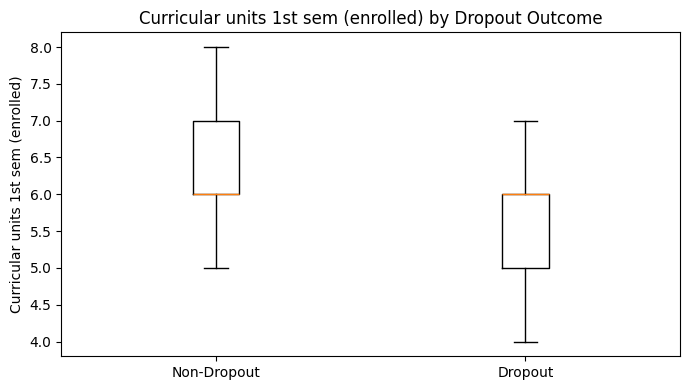

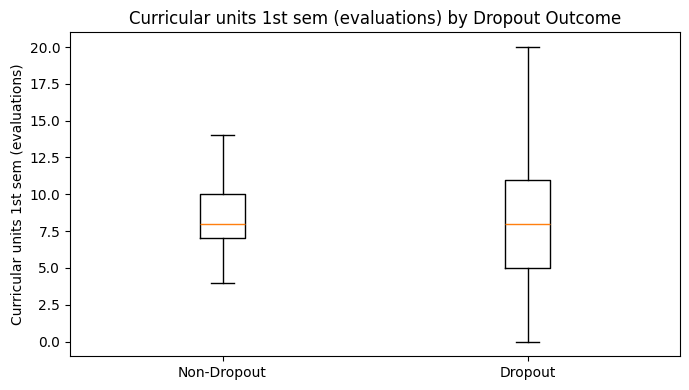

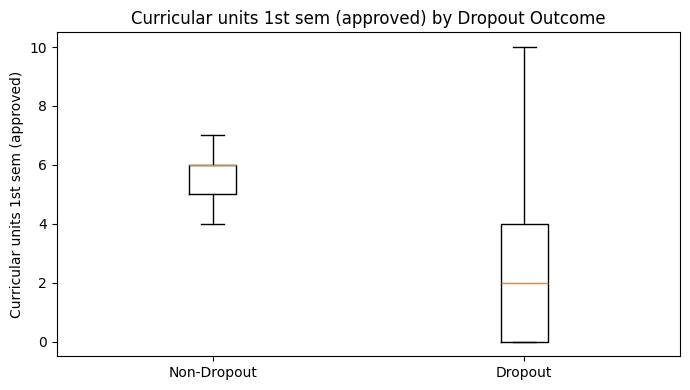

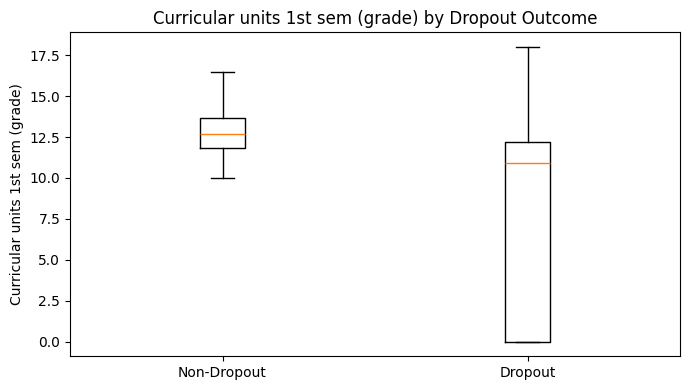

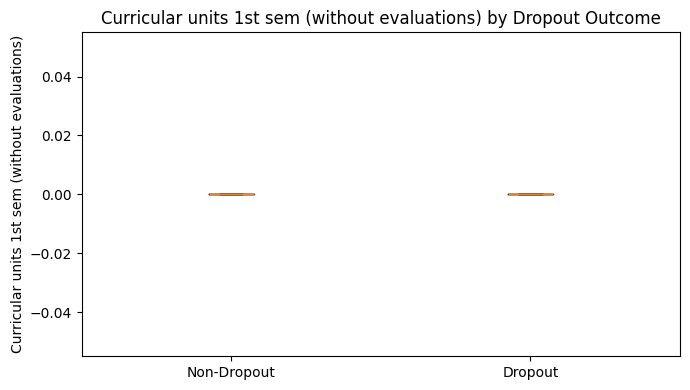

In [23]:
key_sem1_features = [
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)"
]

for col in key_sem1_features:
    non_dropout_vals = df.loc[df["Dropout_binary"] == 0, col]
    dropout_vals = df.loc[df["Dropout_binary"] == 1, col]

    plt.figure(figsize=(7, 4))
    plt.boxplot(
        [non_dropout_vals, dropout_vals],
        tick_labels=["Non-Dropout", "Dropout"],
        showfliers=False
    )
    plt.title(f"{col} by Dropout Outcome")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### **Assessment**

Semester 1 academic performance shows clearer separation between dropout and non-dropout students than the enrollment-stage numerical variables.

The strongest difference appears in `Curricular units 1st sem (approved)`. Non-dropout students are concentrated around a substantially higher number of approved units, while dropout students show lower values and greater variation.

`Curricular units 1st sem (grade)` also shows a clear difference between the two groups. Dropout students have lower grades overall and a much wider distribution, including a substantial number of zero values.

The number of enrolled units and evaluations shows weaker separation, while `Curricular units 1st sem (without evaluations)` appears to provide little distinction because both groups are concentrated at zero.

Overall, these results suggest that Semester 1 completion and performance provide stronger early-warning signals than enrollment-stage grades alone.

## 12. Investigate Zero-Valued Academic Variables

Zero values are checked because they may represent meaningful academic outcomes rather than missing data.


In [24]:
zero_check_features = [
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)"
]

zero_rows = []

for col in zero_check_features:
    zero_mask = df[col] == 0

    zero_rows.append({
        "feature": col,
        "zero_count": int(zero_mask.sum()),
        "zero_pct": round(zero_mask.mean() * 100, 2),
        "dropout_rate_when_zero": round(
            df.loc[zero_mask, "Dropout_binary"].mean() * 100, 2
        ) if zero_mask.any() else np.nan,
        "dropout_rate_when_nonzero": round(
            df.loc[~zero_mask, "Dropout_binary"].mean() * 100, 2
        ) if (~zero_mask).any() else np.nan
    })

zero_analysis = pd.DataFrame(zero_rows)
zero_analysis


,feature,zero_count,zero_pct,dropout_rate_when_zero,dropout_rate_when_nonzero
0,Curricular units 1st sem (enrolled),180,4.07,42.78,31.67
1,Curricular units 1st sem (evaluations),349,7.89,70.49,28.83
2,Curricular units 1st sem (approved),718,16.23,79.39,22.96
3,Curricular units 1st sem (grade),718,16.23,79.39,22.96


In [25]:
same_zero_pattern = (
    (df["Curricular units 1st sem (approved)"] == 0)
    ==
    (df["Curricular units 1st sem (grade)"] == 0)
).mean()

print(f"Same zero/nonzero pattern: {same_zero_pattern:.2%}")

pd.crosstab(
    df["Curricular units 1st sem (approved)"] == 0,
    df["Curricular units 1st sem (grade)"] == 0
)

Same zero/nonzero pattern: 100.00%


Curricular units 1st sem (grade),False,True
Curricular units 1st sem (approved),,
False,3706,0
True,0,718


### **Zero-Pattern Check**

The zero/nonzero pattern for `Curricular units 1st sem (approved)` and `Curricular units 1st sem (grade)` is identical.

All 718 students with zero approved units also have a Semester 1 grade of zero, while all students with at least one approved unit have a nonzero grade.

This means separate binary indicators for zero approved units and zero grade would be redundant.

The original variables will still be retained because they measure different aspects of Semester 1 performance: number of approved units versus average grade.

## 13. Correlation Review for Numerical Features

Correlation is exploratory only and does not imply causation.


In [26]:
numerical_for_corr = [
    "Previous qualification (grade)",
    "Admission grade",
    "Age at enrollment",
    *semester1_features,
    *external_context_features,
    "Dropout_binary"
]

corr_matrix = df[numerical_for_corr].corr(numeric_only=True)

target_correlations = (
    corr_matrix["Dropout_binary"]
    .drop("Dropout_binary")
    .sort_values(key=abs, ascending=False)
    .to_frame("correlation_with_dropout")
)

target_correlations


,correlation_with_dropout
Curricular units 1st sem (grade),-0.480669
Curricular units 1st sem (approved),-0.479112
Age at enrollment,0.254215
Curricular units 1st sem (enrolled),-0.124635
Admission grade,-0.095806
Curricular units 1st sem (evaluations),-0.090125
Previous qualification (grade),-0.078208
Curricular units 1st sem (without evaluations),0.054230
GDP,-0.046319
Curricular units 1st sem (credited),-0.029308


### **Assessment**

The strongest numerical relationships with dropout are found in Semester 1 academic performance.

`Curricular units 1st sem (grade)` and `Curricular units 1st sem (approved)` both show moderately strong negative correlations with dropout. This means students with higher grades and more approved units tend to have lower dropout rates.

`Age at enrollment` shows a weaker but noticeable positive relationship with dropout.

Enrollment-stage grades and Semester 1 enrollment or evaluation counts show much weaker linear relationships.

The macroeconomic variables have correlations close to zero in this dataset.

These correlations are exploratory and should not be interpreted as causal effects or as final measures of feature importance. Nonlinear models may still find useful information in variables with weak Pearson correlation.

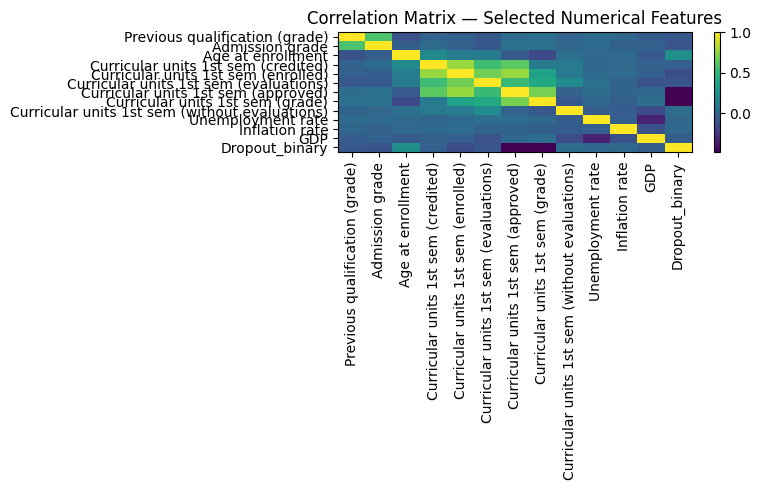

In [27]:
plt.figure(figsize=(8, 5))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix — Selected Numerical Features")
plt.tight_layout()
plt.show()


In [28]:
# Show strongest correlations between predictors
predictor_corr = corr_matrix.drop(
    index="Dropout_binary",
    columns="Dropout_binary"
)

corr_pairs = (
    predictor_corr
    .where(np.triu(np.ones(predictor_corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

corr_pairs.sort_values(
    "abs_correlation",
    ascending=False
).head(10)

,feature_1,feature_2,correlation,abs_correlation
30,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),0.774344,0.774344
39,Curricular units 1st sem (enrolled),Curricular units 1st sem (approved),0.769083,0.769083
51,Curricular units 1st sem (approved),Curricular units 1st sem (grade),0.696113,0.696113
38,Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),0.680220,0.680220
32,Curricular units 1st sem (credited),Curricular units 1st sem (approved),0.628394,0.628394
0,Previous qualification (grade),Admission grade,0.580444,0.580444
31,Curricular units 1st sem (credited),Curricular units 1st sem (evaluations),0.542919,0.542919
45,Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),0.522396,0.522396
46,Curricular units 1st sem (evaluations),Curricular units 1st sem (grade),0.418038,0.418038
40,Curricular units 1st sem (enrolled),Curricular units 1st sem (grade),0.376996,0.376996


## 14. Representation Check for Fairness Variables


In [29]:
fairness_features = [
    "Gender",
    "Age at enrollment",
    "Scholarship holder",
    "Educational special needs",
    "International"
]

for feature in fairness_features:
    print(f"\n--- {feature} ---")

    if feature == "Age at enrollment":
        display(df[feature].describe().to_frame("value"))
    else:
        counts = df[feature].value_counts(dropna=False).to_frame("count")
        counts["percentage"] = (counts["count"] / len(df) * 100).round(2)
        display(counts)



--- Gender ---


,count,percentage
Gender,,
0,2868,64.83
1,1556,35.17



--- Age at enrollment ---


,value
count,4424.000000
mean,23.265145
std,7.587816
min,17.000000
25%,19.000000
50%,20.000000
75%,25.000000
max,70.000000



--- Scholarship holder ---


,count,percentage
Scholarship holder,,
0,3325,75.16
1,1099,24.84



--- Educational special needs ---


,count,percentage
Educational special needs,,
0,4373,98.85
1,51,1.15



--- International ---


,count,percentage
International,,
0,4314,97.51
1,110,2.49


### **Assessment**

`Gender` has sufficient representation in both groups to support a formal fairness comparison later in the project.

`Scholarship holder` also has enough observations in both groups for socioeconomic subgroup analysis.

`Educational special needs` and `International` are highly imbalanced. Only 51 students have recorded special educational needs, while 110 students are international. Results for these groups will therefore be treated as descriptive rather than used as strong evidence of model fairness or unfairness.

`Age at enrollment` will remain continuous for predictive modeling. Age groups may be created later specifically for fairness analysis, with group sizes checked before comparisons are made.

Based on representation, the primary fairness audit will focus on `Gender` and age groups, while the other variables will provide supporting subgroup analysis where sample sizes permit.

## 15. Enrollment vs. Semester 1 Signal Comparison

This compares simple group differences only. It is not a model-performance comparison.


In [30]:
comparison_features = [
    "Admission grade",
    "Previous qualification (grade)",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (evaluations)"
]

comparison_rows = []

for col in comparison_features:
    means = df.groupby("Dropout_binary")[col].mean()

    comparison_rows.append({
        "feature": col,
        "non_dropout_mean": means.get(0, np.nan),
        "dropout_mean": means.get(1, np.nan),
        "absolute_mean_difference": abs(means.get(1, np.nan) - means.get(0, np.nan))
    })

signal_comparison = pd.DataFrame(comparison_rows)
signal_comparison.sort_values("absolute_mean_difference", ascending=False)


,feature,non_dropout_mean,dropout_mean,absolute_mean_difference
4,Curricular units 1st sem (grade),12.242187,7.256656,4.985531
2,Age at enrollment,21.938395,26.068966,4.130571
3,Curricular units 1st sem (approved),5.726274,2.551724,3.174550
0,Admission grade,127.932434,124.961365,2.971069
1,Previous qualification (grade),133.322744,131.114075,2.208669
5,Curricular units 1st sem (evaluations),8.558109,7.751583,0.806525


In [31]:
def cohens_d(non_dropout, dropout):
    n1 = len(non_dropout)
    n2 = len(dropout)

    var1 = non_dropout.var(ddof=1)
    var2 = dropout.var(ddof=1)

    pooled_std = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2)
        / (n1 + n2 - 2)
    )

    return (
        (non_dropout.mean() - dropout.mean()) / pooled_std
        if pooled_std != 0 else np.nan
    )


effect_rows = []

for col in comparison_features:
    non_dropout = df.loc[df["Dropout_binary"] == 0, col]
    dropout = df.loc[df["Dropout_binary"] == 1, col]

    effect_rows.append({
        "feature": col,
        "non_dropout_mean": non_dropout.mean(),
        "dropout_mean": dropout.mean(),
        "cohens_d": cohens_d(non_dropout, dropout)
    })

effect_size_comparison = pd.DataFrame(effect_rows)

effect_size_comparison["abs_cohens_d"] = (
    effect_size_comparison["cohens_d"].abs()
)

effect_size_comparison.sort_values(
    "abs_cohens_d",
    ascending=False
)

,feature,non_dropout_mean,dropout_mean,cohens_d,abs_cohens_d
4,Curricular units 1st sem (grade),12.242187,7.256656,1.173646,1.173646
3,Curricular units 1st sem (approved),5.726274,2.551724,1.168710,1.168710
2,Age at enrollment,21.938395,26.068966,-0.562797,0.562797
0,Admission grade,127.932434,124.961365,0.206081,0.206081
5,Curricular units 1st sem (evaluations),8.558109,7.751583,0.193757,0.193757
1,Previous qualification (grade),133.322744,131.114075,0.167967,0.167967


## 16. EDA Findings to Carry Forward

### Enrollment-Stage Findings

Enrollment-stage variables provide some useful early signals, but most show only modest separation between dropout and non-dropout students.

The clearest enrollment-stage patterns are:

- older students have a higher dropout rate and show a moderate standardized difference
- students with lower admission grades have somewhat higher dropout risk
- financial and administrative variables show strong differences in dropout rates
- students with unpaid tuition and debtor status have substantially higher dropout rates
- scholarship holders have substantially lower dropout rates than non-scholarship holders

Course and application mode also show meaningful variation in dropout rates, although rare categories need to be handled carefully.

### Semester 1 Findings

Semester 1 academic performance provides much stronger separation between dropout and non-dropout students.

The strongest indicators are:

- Semester 1 grade
- number of approved Semester 1 units

Both show large standardized differences between the two groups.

Zero approved units and zero Semester 1 grade are also strongly associated with dropout. These two zero patterns occur in exactly the same students, so separate binary indicators for both would be redundant.

### Fairness and Representation Findings

`Gender` has enough representation in both groups to support formal fairness evaluation.

Age can also support fairness analysis if grouped carefully.

`Educational special needs` and `International` have very small minority groups, so results for these variables should be treated as descriptive rather than used for strong fairness conclusions.

### Data Issues to Carry Forward

No major data-quality problems were identified.

Important considerations for the next stage are:

- several categorical variables require proper encoding
- some course and application-mode categories are rare
- age is right-skewed but should not be treated automatically as an outlier problem
- several Semester 1 variables are strongly correlated
- financial variables need timing verification before inclusion in the enrollment-stage model

### Working Interpretation

The EDA supports the project's two-stage early-warning design.

Enrollment-stage information can provide an earlier but weaker signal of dropout risk. Semester 1 academic performance provides much stronger information, particularly through approved units and grades.

The next stage will focus on preparing these features for modeling while preserving the distinction between information available at enrollment and information available after Semester 1.

## 17. Decisions for Feature Engineering

Based on the EDA, the following decisions will guide the feature-engineering stage.

### Numerical Features

`Age at enrollment`, admission grade, previous-qualification grade, and the Semester 1 academic variables will remain numerical.

Age is right-skewed, but older students appear to be valid observations rather than data errors. Age will therefore remain continuous for modeling.

Scaling will be applied only where required by the model, particularly for linear models such as Logistic Regression.

### Categorical Features

Coded variables such as `Course`, `Application mode`, `Marital status`, parental qualification and occupation, gender, scholarship status, debtor status, and tuition-payment status will be treated as categorical rather than continuous numerical variables.

Appropriate encoding will be applied during preprocessing.

### Rare Categories

`Course` and `Application mode` contain categories with very small sample sizes.

Rare categories may be grouped into an `Other` category to reduce sparsity. The grouping threshold will be selected during feature engineering rather than based only on dropout rate.

### Enrollment-Stage Features

The enrollment-stage model will use variables available at or near enrollment, together with eligible external-context variables.

Semester 1 and Semester 2 academic variables will be excluded.

`Debtor` and `Tuition fees up to date` will only be included after confirming that their values are available at the intended prediction point.

### First-Semester Features

The first-semester model will use the eligible enrollment-stage variables plus Semester 1 academic information.

Semester 2 variables will remain excluded.

### New Academic Progress Features

Semester 1 ratio features will be explored, including:

- approved units / enrolled units
- evaluations / enrolled units
- approved units / evaluations, where meaningful

These may provide more interpretable measures of academic progress than raw counts alone.

Separate binary indicators for zero approved units and zero Semester 1 grade will not both be created because their zero/nonzero patterns are identical.

### Fairness Variables

`Gender` and age groups will be retained for later fairness evaluation.

Age will remain continuous for modeling but may also be grouped separately for subgroup analysis.

`Educational special needs` and `International` will be treated cautiously because of their small minority-group counts.

### Class Imbalance

No resampling will be applied before baseline modeling.

Class weighting, threshold adjustment, or resampling will only be considered after baseline model performance is evaluated.

### Features Removed at This Stage

No predictors are permanently removed based on EDA alone.

Feature selection decisions will be made after preprocessing and baseline modeling.